# Lab 5, Module 1: Prompting Foundations

### *Tying Embedding to LLM *

**Estimated time: 15-20 minutes**

	-Try prompting in ChatGPT/Claude
	-Zero-shot, few-shot, chain-of-thought
	-Hallucination demo
	-Libraries: none


In [1]:
# This cell:
#   • Loads a small, free word embedding model (GloVe)
#   
#
# NOTE: The first time you run this, it will download the model (~70MB),
#       which may take up to a minute in Colab.

import numpy as np
import matplotlib.pyplot as plt

try:
    import gensim.downloader as api
except ImportError:
    !pip install -q gensim
    import gensim.downloader as api

from sklearn.metrics.pairwise import cosine_similarity

### Loading a set of pre-embedded words

The gensim downloader will load a large set of words that already have been embedded into an abstract vector representation.  

In [2]:
# ============================================================
#  Module 1 — Activity 0: Word-level Embedding
#  DATA 1010 – Artificial Intelligence in Action
# ============================================================



# -----------------------------
# 1. Load a pre-trained word embedding model
# -----------------------------
# Check if the model is already loaded to avoid reloading
if 'w2v' not in locals():
    print("Loading GloVe word vectors (glove-wiki-gigaword-50)...")
    w2v = api.load("glove-wiki-gigaword-50")  # 50-dimensional GloVe
    print("Model loaded!")
    print(f"Vocabulary size: {len(w2v.index_to_key):,} words")
    print(f"Vector dimension: {w2v.vector_size} dimensions\n")
else:
    print("GloVe word vectors (w2v) already loaded.\n")



Loading GloVe word vectors (glove-wiki-gigaword-50)...
[==================================================] 100.0% 66.0/66.0MB downloaded
Model loaded!
Vocabulary size: 400,000 words
Vector dimension: 50 dimensions



### Let's take a look at a few of the words and how they are represented

In [17]:

np.set_printoptions(precision=3,linewidth=60)
w = "galaxy"
print(f"word: {w:20s} ")
print(f"Length of embedding: {len(w2v[w])}")
print(f"embedding: \n{ w2v[w]}\n")

word: galaxy               
Length of embedding: 50
embedding: 
[ 1.503  0.523  0.638  0.995  0.509 -0.454 -0.891 -0.555
 -0.866  0.401  1.217  0.321 -0.387  0.792  0.256 -0.01
 -0.054  0.115 -2.241  0.188 -1.482 -1.113 -0.557  0.382
 -0.397 -0.155  0.166  0.704 -0.202 -0.946  0.924  0.522
  0.261 -1.053 -0.993 -0.142 -0.435 -0.346  0.255 -0.549
  0.594 -0.341 -0.235  0.205 -0.743  0.325  1.007  0.183
 -0.295 -0.364]



### Understanding the dimensions

We can the vectors of a bunch of words an see how this looks on a 2d chart.  Each line represents the embedding of a different word.  You can't really tell a lot by looking at the graph, but notice the peak around parameter 30.   That value seems to be higher for "person" and "table" than for "galaxy" and "atom".


word: galaxy               
word: person               
word: table                
word: atom                 


Text(0, 0.5, 'value')

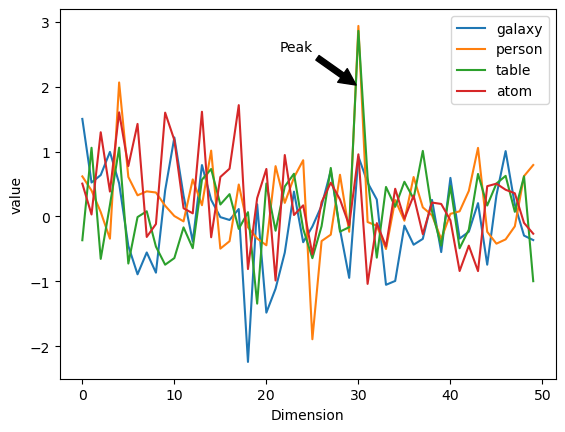

In [29]:
science_words =  ["galaxy", "person", "table", "atom"]
x = list(range(50))
np.set_printoptions(precision=3,linewidth=60)
for w in science_words:
    print(f"word: {w:20s} ")
    y = w2v[w]
    plt.plot(x,y, label=w)
    
plt.annotate('Peak', xy=(30, 2), xytext=(25, 2.5),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='right', va='bottom')
plt.legend ( )
plt.xlabel( "Dimension")
plt.ylabel("value")

### Let's explroe this parameter a bit.

1) Take a bunch of science words - find all their vectors and average them
2) Take a bunch of non-science words - find all their vectors and averge them
3) Subtract the non-science from the science, and plot the results

Text(0, 0.5, 'displacement from non-science words to science words')

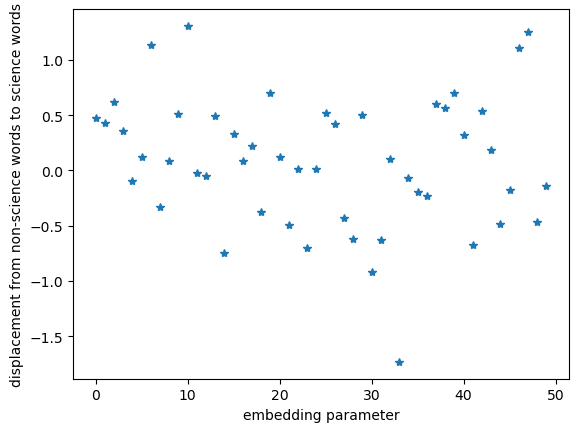

In [51]:
science_words = science_words + ["galaxy", "atom", "molecule", "quantum","telescope", "cell", "nucleus", "research", "experiment"]
nonscience_words = ["cat", "dog", "pizza", "music", "tree", "happy", "running", "house"]


science_average = np.zeros(50)
science_ct = 0
for w in science_words:
  word_vector = w2v[w]
  science_average = science_average + np.array(word_vector)
  science_ct = science_ct + 1
science_average = science_average / science_ct
  
nonscience_average = np.zeros(50)
nonscience_ct = 0
for w in nonscience_words:
  word_vector = w2v[w]
  nonscience_average = nonscience_average + np.array(word_vector)
  nonscience_ct = nonscience_ct + 1
nonscience_average = nonscience_average / nonscience_ct
  
science_displacement = science_average - nonscience_average
x = np.array(list(range(50)))

plt.plot(x,science_displacement,"*")
plt.xlabel("embedding parameter")
plt.ylabel("displacement from non-science words to science words")


### What happened?

There are clear differences between science words and non-science words.  However, the biggest displayment seems to be parameter 33 where the diference science words average about 1.7 lower than non-science words.

Let's explore this with some other science words and see what happens with parameter 33 and a few other random parameters.

In [91]:
new_science_words = ["economics", "microbiology","zoology","biochemistry","oceanography","science","chemistry","physics","biology","meteorology","geology","mathematics","astronomy","astrophysics"]

p1 = np.random.randint(32)
p2 = np.random.randint(16) + 34

print(f"  word                  P: 33     P: {p1:02d}    P:{p2:02d}")
wlist = []
for w in new_science_words:
  wa = w2v[w]
  wlist.append(wa)
  print(f"{w:20s} {wa[33]-nonscience_average[33]:>8.3f}  " \
    + f"{wa[p1]-nonscience_average[p1]:>8.3f} " \
    + f"{wa[p2]-nonscience_average[p2]:>8.3f} ")

  word                  P: 33     P: 23    P:38
economics              -1.520    -0.703    1.482 
microbiology           -2.066    -1.129    1.609 
zoology                -2.433    -1.301    1.028 
biochemistry           -2.372    -0.564    1.788 
oceanography           -2.647    -1.488    1.964 
science                -2.409    -0.721    0.676 
chemistry              -2.534    -0.893    1.460 
physics                -2.626    -0.964    1.147 
biology                -2.491    -0.494    1.473 
meteorology            -1.985    -1.511    1.454 
geology                -2.307    -1.471    1.371 
mathematics            -2.139    -0.191    0.522 
astronomy              -2.273    -0.669    0.078 
astrophysics           -2.244    -1.123    1.131 


### Is parameter 33 how "science-ey" a word is?

No.  

However, you can see from above, parameter 33 seems to be a fairly reliable marker of how "science-ey" a word is. Physics is very "science-ey" (P33 = -2.626) and economics is moderately "science-ey" (P33=-1.520).   However, the actual meaning of parameter 33 is more complex.  It is just aligned somewhat with the concept we call science.  It is NOT actually this, but something that machine has figured out as an important concept in understanding the relationships between words.